In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')

In [3]:
df.columns = df.columns.str.strip()

In [4]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,15-12-2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01-03-2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25-02-2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24-11-2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22-12-2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9837 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [6]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [7]:
# Check Duplicate Values

df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes


Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count            object
Vote_Average          object
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

In [9]:
# Convert into Numeric Values

df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

In [10]:
df.dtypes

Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count           float64
Vote_Average         float64
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

In [11]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9826.000000,9826.000000
mean,40.320570,1392.943721,6.439467
std,108.874308,2611.303856,1.129797
min,7.100000,0.000000,0.000000
25%,16.127500,146.000000,5.900000
50%,21.191000,444.000000,6.500000
75%,35.174500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [12]:
df['Vote_Count'] = df['Vote_Count'].astype('Int64')

In [13]:
# Change data type of Release Date 

df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce', dayfirst=True)

In [14]:
# Step 2: Extract year (creates float if NaT present)

df['Release_Date'] = df['Release_Date'].dt.year


In [15]:
# Step 3: Convert to integer safely
# Option A: If NaN is not here.
# df['Release_Year'] = df['Release_Year'].astype(int)

# Option B: Maybe NaN (recommended)
df['Release_Date'] = df['Release_Date'].astype('Int64')

In [16]:
# Step 4: Check dtype

print(df['Release_Date'].dtypes)

Int64


In [17]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [18]:
# Remove Some Unusual Columns

cols = df.drop(['Overview','Original_Language','Poster_Url'], axis=1, inplace=True)

In [19]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


### **Categorizing Vote_Average column**

We Would cut the **Vote_Average** values and make 4 categories **popular, average, below_avg, not_popular** to describe it more using **catigorize_col()** function provided above

In [20]:
def catigorize_col (df, cols, labels):
  
  edges = [df[cols].describe()['min'],
           df[cols].describe()['25%'],
           df[cols].describe()['50%'],
           df[cols].describe()['75%'],
           df[cols].describe()['max']
           ]
  
  df[cols] = pd.cut(df[cols], edges, labels=labels, duplicates='drop')
  return df

In [21]:
labels = ['not_popular','below_avg','average','popular']
catigorize_col(df,'Vote_Average',labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [22]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [23]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [24]:
df.dropna(inplace=True)

df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

#### **We did split genres into a list and then explode our dataframe to have only one genre per row for each movie**

In [25]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [26]:
# Casting column into Category

df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25551 non-null  Int64   
 1   Title         25551 non-null  object  
 2   Popularity    25551 non-null  float64 
 3   Vote_Count    25551 non-null  Int64   
 4   Vote_Average  25551 non-null  category
 5   Genre         25551 non-null  category
dtypes: Int64(2), category(2), float64(1), object(1)
memory usage: 899.3+ KB


In [28]:
df.nunique()

Release_Date     100
Title           9414
Popularity      8087
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [29]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


## **Data Visualization**

In [30]:
sns.set_style('whitegrid')

### What is the most frequent genre of movies released on Netflix?

In [31]:
df['Genre'].describe()

count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

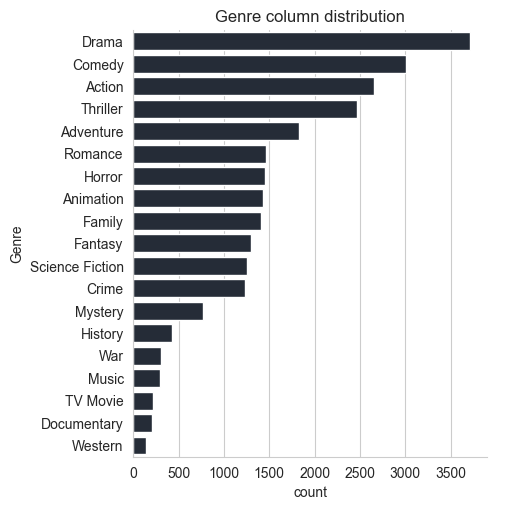

In [32]:
sns.catplot(y = 'Genre', data = df, kind='count', order = df['Genre'].value_counts().index, color="#222b3a")
plt.title('Genre column distribution')
plt.show()

### Which is highest votes in vote avg column?

In [33]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


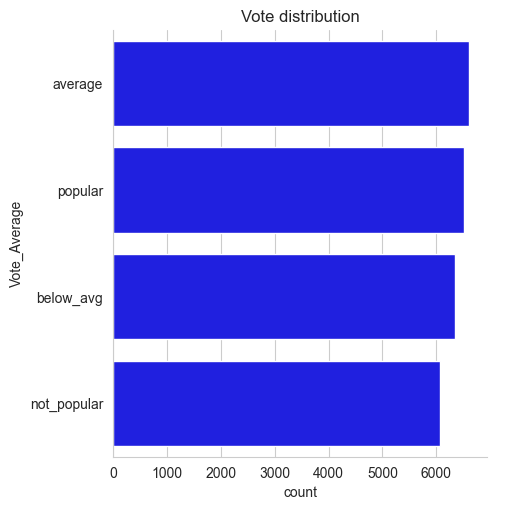

In [34]:
sns.catplot(y = 'Vote_Average', data = df, kind='count', order = df['Vote_Average'].value_counts().index, color="blue")
plt.title('Vote distribution')
plt.show()

### What Movie got the highest popularity ? What's its genre?

In [35]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure


In [36]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


### What Movie got the lowest popularity ? What's its genre?

In [37]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25545,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25547,2021,The United States vs. Billie Holiday,13.354,152,average,History
25548,1984,Threads,13.354,186,popular,War
25549,1984,Threads,13.354,186,popular,Drama
25550,1984,Threads,13.354,186,popular,Science Fiction


### Which year has the most filmmed movies?

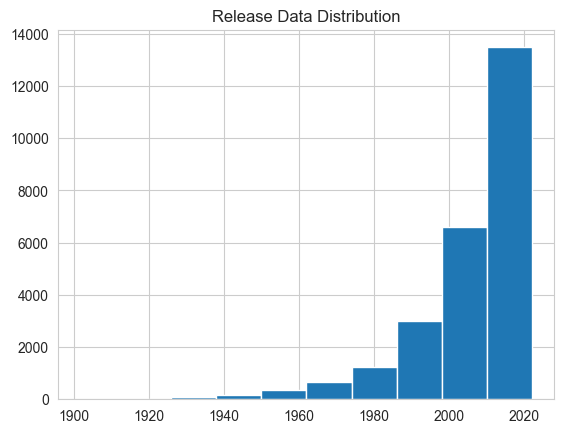

In [38]:
df['Release_Date'].hist()
plt.title("Release Data Distribution")
plt.show()

### Average Popularity & Vote by Genre

C:\Users\rohit\AppData\Local\Temp\ipykernel_13728\1181816994.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_stats = df.groupby('Genre').agg({'Popularity':'mean', 'Vote_Average':'count'}).sort_values(by='Popularity', ascending=False)
C:\Users\rohit\AppData\Local\Temp\ipykernel_13728\1181816994.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_stats.index, y=genre_stats['Popularity'], palette='viridis')


                 Popularity  Vote_Average
Genre                                    
Adventure         53.785530          1829
Fantasy           52.986726          1295
Animation         52.443201          1425
Action            50.688837          2652
Science Fiction   49.241125          1255
Family            46.458322          1405
Crime             44.625692          1235
Thriller          43.024233          2473
Mystery           40.325880           765
Horror            38.442648          1457
Comedy            37.834018          3006
Western           36.187912           137
War               35.321010           307
Music             33.863749           291
Romance           30.837862          1461
Drama             30.110546          3715
TV Movie          29.954715           214
Documentary       29.737700           203
History           28.429601           426


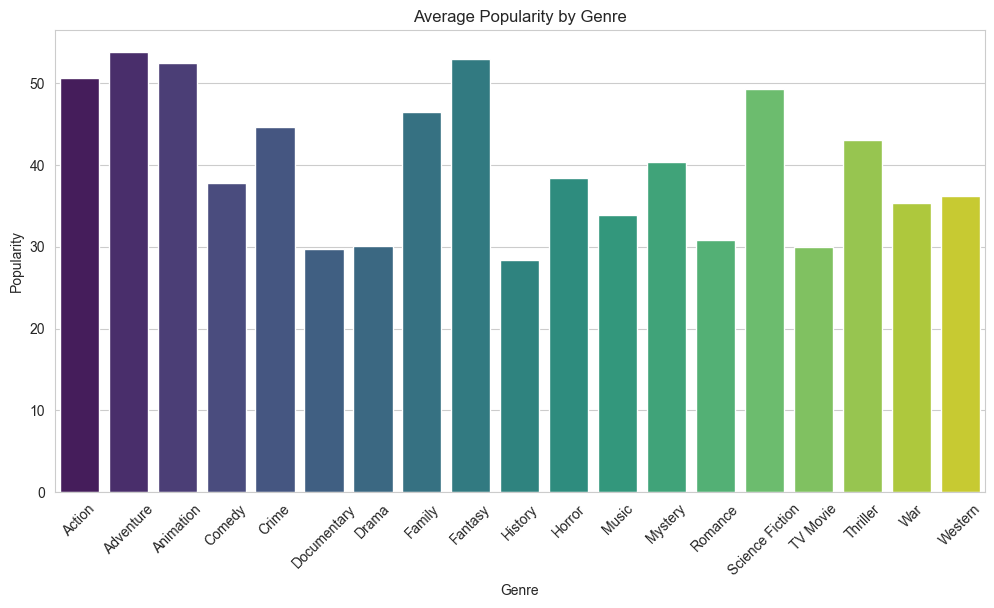

In [39]:
# Group by Genre and calculate mean popularity and vote average
genre_stats = df.groupby('Genre').agg({'Popularity':'mean', 'Vote_Average':'count'}).sort_values(by='Popularity', ascending=False)
print(genre_stats)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x=genre_stats.index, y=genre_stats['Popularity'], palette='viridis')
plt.xticks(rotation=45)
plt.title('Average Popularity by Genre')
plt.show()

### Year-wise Trend of Number of Movies Released

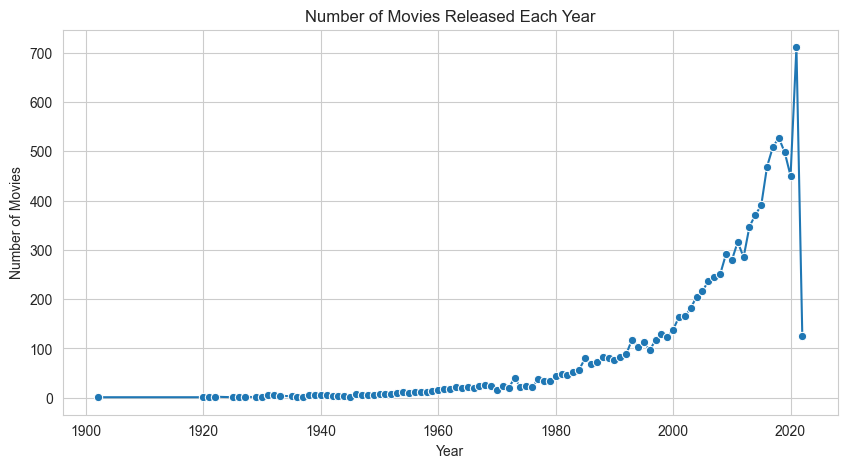

In [40]:
# Count movies per year
yearly_count = df.groupby('Release_Date')['Title'].nunique()

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_count.index, y=yearly_count.values, marker='o')
plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

### Top 10 Most Popular Movies

                     Title  Popularity            Genre
0  Spider-Man: No Way Home    5083.954           Action
1  Spider-Man: No Way Home    5083.954        Adventure
2  Spider-Man: No Way Home    5083.954  Science Fiction
3               The Batman    3827.658            Crime
4               The Batman    3827.658          Mystery
5               The Batman    3827.658         Thriller
6                  No Exit    2618.087         Thriller
7                  Encanto    2402.201        Animation
8                  Encanto    2402.201           Comedy
9                  Encanto    2402.201           Family


C:\Users\rohit\AppData\Local\Temp\ipykernel_13728\1618846692.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Title', data=top_movies, palette='coolwarm')


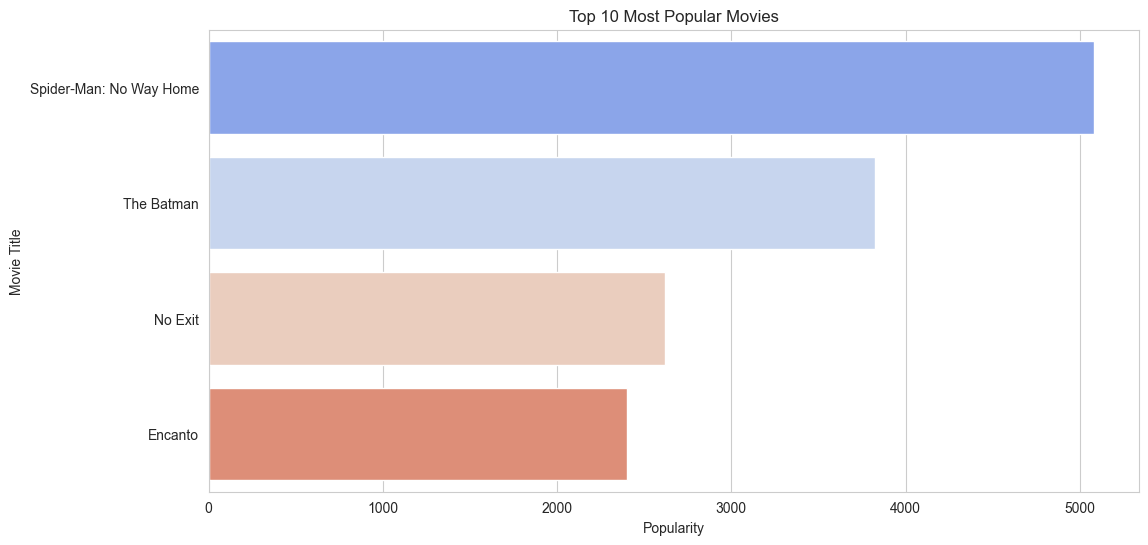

In [41]:
# Top 10 movies by popularity
top_movies = df[['Title', 'Popularity', 'Genre']].drop_duplicates().sort_values(by='Popularity', ascending=False).head(10)
print(top_movies)

# Bar plot
plt.figure(figsize=(12,6))
sns.barplot(x='Popularity', y='Title', data=top_movies, palette='coolwarm')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity')
plt.ylabel('Movie Title')
plt.show()

 
 ### **Conclusion**
 
 **Q1: What is the most frequent genre in the dataset?**

Drama genre is the most frequent genre in our dataset and has appeared more than 14% of the times among 19 other genres.

**Q2: What genres has highest votes ?**

we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the highest popularity among fans by being having more than 18.5% of movies popularities.

**Q3: What movie got the highest popularity ? what's its Action , genre ?**

Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Adventure and Sience Fiction .

**Q4: What movie got the lowest popularity ? what's its genre ?**

The united states, thread' has the highest lowest rate in our dataset 
and it has genres of music, drama, 'war', 'sci-fi' and history`.

**Q5: Which year has the most filmmed movies?**

year 2020 has the highest filmming rate in our dataset.

**Q6: Which genres are most popular on average?**

Action, Adventure, and Science Fiction movies have the highest average popularity, even though Drama has more movies overall.

**Q7: How does movie popularity change over the years?**

Popularity and production trends show peaks in certain years, with 2020 being the busiest year. Other years show steady changes, highlighting trends in genre production.

**Q8: Which are the top 10 most popular movies?**

Spider-Man: No Way Home, The Batman, and Encanto are among the top 10 movies by popularity. These titles dominate popularity across Adventure, Action, and Animation genres.
